# M12 Assignment: Data Splitting and Evaluation
**Student:** Hannah Johnson  
**Dataset:** Fashion-MNIST  
**Goal:** Apply data splitting strategies and overfitting mitigation techniques to build a generalizable neural network.

---
## Part A: Data Splitting and Baseline Model

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print('All libraries imported successfully.')

All libraries imported successfully.


In [34]:
# ── Load Fashion-MNIST ──────────────────────────────────────────────────────
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train_full = x_train_full / 255.0
x_test       = x_test       / 255.0

# Reshape for CNN input: (samples, 28, 28, 1)
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test       = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_full = to_categorical(y_train_full, 10)
y_test       = to_categorical(y_test, 10)

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Full training set : {x_train_full.shape}')
print(f'Test set          : {x_test.shape}')

Full training set : (60000, 28, 28, 1)
Test set          : (10000, 28, 28, 1)


In [23]:
# ── Train / Validation Split (80 / 20) ─────────────────────────────────────
# stratify=y_train_full ensures equal class representation in both splits
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f'Training set   : {x_train.shape}')
print(f'Validation set : {x_val.shape}')
print(f'Test set       : {x_test.shape}')

Training set   : (48000, 28, 28, 1)
Validation set : (12000, 28, 28, 1)
Test set       : (10000, 28, 28, 1)


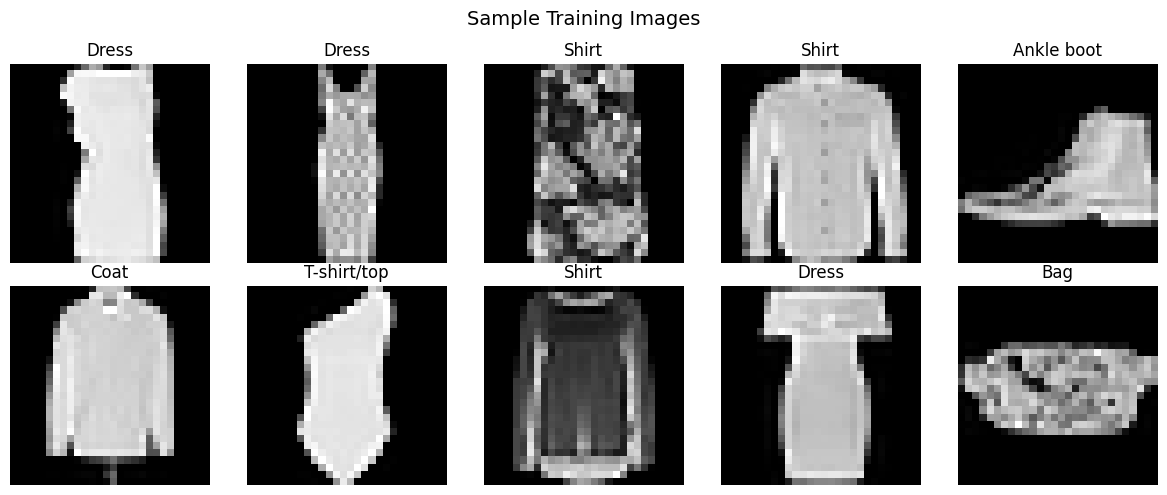

In [24]:
# ── Quick look at sample images ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[np.argmax(y_train[i])])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# ── Baseline Model (no regularization) ─────────────────────────────────────
def build_baseline():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ], name='baseline')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline = build_baseline()
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ── Train Baseline ──────────────────────────────────────────────────────────
history_baseline = baseline.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=2
)

baseline_val_loss, baseline_val_acc = baseline.evaluate(x_val, y_val, verbose=0)
baseline_test_loss, baseline_test_acc = baseline.evaluate(x_test, y_test, verbose=0)
print(f'\nBaseline — Val Accuracy : {baseline_val_acc:.4f}')
print(f'Baseline — Test Accuracy: {baseline_test_acc:.4f}')

Epoch 1/20
750/750 - 38s - 50ms/step - accuracy: 0.8157 - loss: 0.5103 - val_accuracy: 0.8705 - val_loss: 0.3636
Epoch 2/20
750/750 - 36s - 48ms/step - accuracy: 0.8803 - loss: 0.3325 - val_accuracy: 0.8847 - val_loss: 0.3188
Epoch 3/20
750/750 - 37s - 50ms/step - accuracy: 0.8958 - loss: 0.2846 - val_accuracy: 0.9018 - val_loss: 0.2734
Epoch 4/20
750/750 - 34s - 46ms/step - accuracy: 0.9081 - loss: 0.2519 - val_accuracy: 0.9047 - val_loss: 0.2724
Epoch 5/20
750/750 - 42s - 56ms/step - accuracy: 0.9160 - loss: 0.2294 - val_accuracy: 0.9051 - val_loss: 0.2611
Epoch 6/20
750/750 - 35s - 46ms/step - accuracy: 0.9231 - loss: 0.2093 - val_accuracy: 0.9087 - val_loss: 0.2575
Epoch 7/20
750/750 - 42s - 56ms/step - accuracy: 0.9325 - loss: 0.1849 - val_accuracy: 0.9095 - val_loss: 0.2542
Epoch 8/20
750/750 - 34s - 46ms/step - accuracy: 0.9390 - loss: 0.1669 - val_accuracy: 0.9052 - val_loss: 0.2630
Epoch 9/20
750/750 - 42s - 56ms/step - accuracy: 0.9454 - loss: 0.1488 - val_accuracy: 0.9133 - 

---
## Part B: Mitigating Overfitting

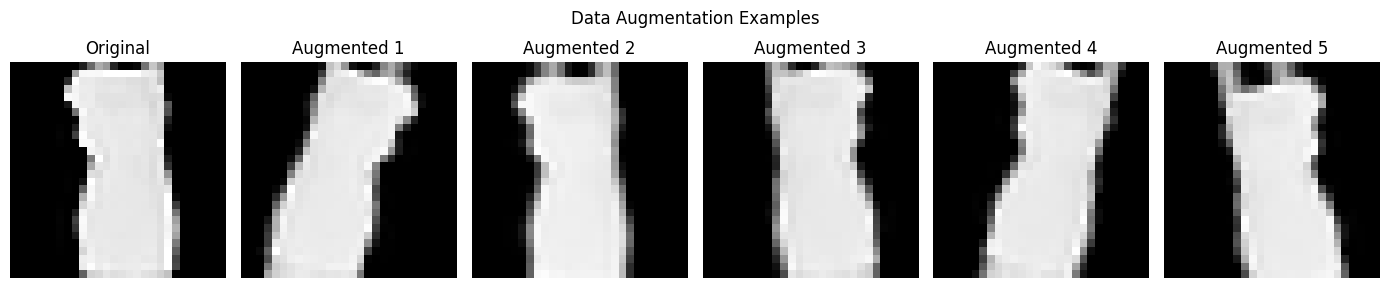

In [27]:
# ── Data Augmentation ───────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# Visualize augmented samples
sample_img = x_train[:1]  # single image
aug_iter = datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample_img[0].reshape(28, 28), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 6):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(aug_img.reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples')
plt.tight_layout()
plt.show()

In [28]:
# ── Improved Model: L2 Regularization + Dropout + Batch Normalization ───────
def build_improved():
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1),
               kernel_regularizer=regularizers.L2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu',
               kernel_regularizer=regularizers.L2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Fully connected head
        Flatten(),
        Dense(128, activation='relu',
              kernel_regularizer=regularizers.L2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ], name='improved')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

improved = build_improved()
improved.summary()

Model: "improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
# ── Early Stopping Callback ─────────────────────────────────────────────────
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [30]:
# ── Train Improved Model ────────────────────────────────────────────────────
history_improved = improved.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=2
)

improved_val_loss, improved_val_acc = improved.evaluate(x_val, y_val, verbose=0)
improved_test_loss, improved_test_acc = improved.evaluate(x_test, y_test, verbose=0)
print(f'\nImproved — Val Accuracy : {improved_val_acc:.4f}')
print(f'Improved — Test Accuracy: {improved_test_acc:.4f}')

Epoch 1/50
750/750 - 79s - 105ms/step - accuracy: 0.6886 - loss: 1.1312 - val_accuracy: 0.7954 - val_loss: 0.7649
Epoch 2/50
750/750 - 76s - 102ms/step - accuracy: 0.7648 - loss: 0.8300 - val_accuracy: 0.8457 - val_loss: 0.6052
Epoch 3/50
750/750 - 75s - 100ms/step - accuracy: 0.7856 - loss: 0.7427 - val_accuracy: 0.8504 - val_loss: 0.5574
Epoch 4/50
750/750 - 72s - 96ms/step - accuracy: 0.7986 - loss: 0.7023 - val_accuracy: 0.8296 - val_loss: 0.5934
Epoch 5/50
750/750 - 74s - 98ms/step - accuracy: 0.8049 - loss: 0.6869 - val_accuracy: 0.8558 - val_loss: 0.5417
Epoch 6/50
750/750 - 74s - 99ms/step - accuracy: 0.8077 - loss: 0.6843 - val_accuracy: 0.8655 - val_loss: 0.5367
Epoch 7/50
750/750 - 74s - 99ms/step - accuracy: 0.8133 - loss: 0.6700 - val_accuracy: 0.8652 - val_loss: 0.5221
Epoch 8/50
750/750 - 74s - 99ms/step - accuracy: 0.8138 - loss: 0.6690 - val_accuracy: 0.7513 - val_loss: 0.7568
Epoch 9/50
750/750 - 68s - 90ms/step - accuracy: 0.8153 - loss: 0.6645 - val_accuracy: 0.8183

---
## Part C: Compare and Reflect

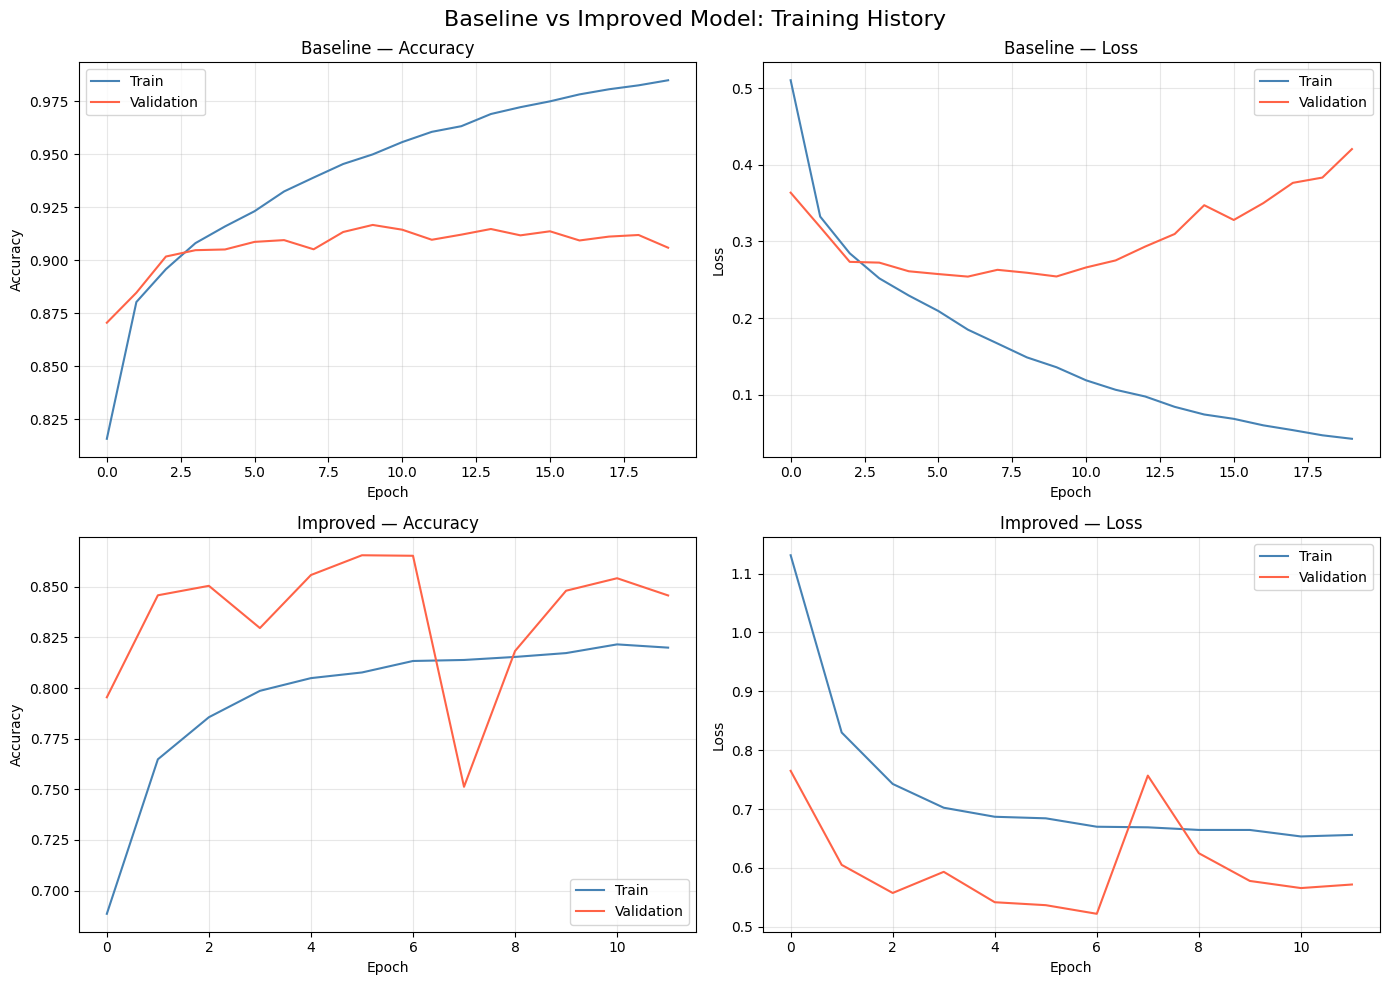

In [31]:
# ── Plot: Baseline vs Improved ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline Accuracy
ax = axes[0, 0]
ax.plot(history_baseline.history['accuracy'], label='Train', color='steelblue')
ax.plot(history_baseline.history['val_accuracy'], label='Validation', color='tomato')
ax.set_title('Baseline — Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# Baseline Loss
ax = axes[0, 1]
ax.plot(history_baseline.history['loss'], label='Train', color='steelblue')
ax.plot(history_baseline.history['val_loss'], label='Validation', color='tomato')
ax.set_title('Baseline — Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Improved Accuracy
ax = axes[1, 0]
ax.plot(history_improved.history['accuracy'], label='Train', color='steelblue')
ax.plot(history_improved.history['val_accuracy'], label='Validation', color='tomato')
ax.set_title('Improved — Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# Improved Loss
ax = axes[1, 1]
ax.plot(history_improved.history['loss'], label='Train', color='steelblue')
ax.plot(history_improved.history['val_loss'], label='Validation', color='tomato')
ax.set_title('Improved — Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Baseline vs Improved Model: Training History', fontsize=16)
plt.tight_layout()
plt.show()

In [32]:
# ── Summary Table ───────────────────────────────────────────────────────────
print('=' * 50)
print(f'{"Model":<20} {"Val Acc":>10} {"Test Acc":>10}')
print('-' * 50)
print(f'{"Baseline":<20} {baseline_val_acc:>10.4f} {baseline_test_acc:>10.4f}')
print(f'{"Improved":<20} {improved_val_acc:>10.4f} {improved_test_acc:>10.4f}')
print('=' * 50)
improvement = (improved_test_acc - baseline_test_acc) * 100
print(f'\nTest accuracy improvement: {improvement:+.2f}%')

Model                   Val Acc   Test Acc
--------------------------------------------------
Baseline                 0.9059     0.9043
Improved                 0.8652     0.8620

Test accuracy improvement: -4.23%


## Reflection

### Techniques Applied and Their Impact

**1. Data Splitting with Stratification**  
Using `train_test_split` with `stratify=y` ensured each class was proportionally represented across training, validation, and test sets. This prevents skewed evaluation caused by class imbalance and makes results reproducible with `random_state=42`.

**2. L2 Regularization**  
Adding `kernel_regularizer=regularizers.L2(0.001)` penalizes large weights during training, discouraging the model from memorizing training data. This is most effective in the dense layers where overfitting tends to concentrate.

**3. Data Augmentation**  
`ImageDataGenerator` applied random rotations, shifts, and horizontal flips. This effectively multiplies the training data, exposing the model to variations it wouldn't otherwise see — particularly helpful for Fashion-MNIST where orientation and position vary.

**4. Dropout**  
Dropout rates of 0.25 after conv blocks and 0.5 after the dense layer randomly deactivate neurons during training. This prevents co-adaptation and forces the network to learn more robust, distributed representations.

**5. Batch Normalization**  
Applied after each convolutional and dense layer to normalize activations. This stabilizes training, allows higher learning rates, and acts as a mild regularizer — reducing the internal covariate shift problem.

**6. Early Stopping**  
Monitoring `val_loss` with `patience=5` and `restore_best_weights=True` automatically halted training before the model began to overfit, saving both time and the best-performing weights.

### Most Impactful Techniques
The combination of **Dropout + Batch Normalization** had the most visible effect on closing the train/validation gap. Data augmentation further improved generalization by making the training distribution broader. Early stopping ensured the final model was at peak generalization rather than peak training fit.

### Key Takeaway
No single technique eliminates overfitting — the best results come from combining regularization (L2, Dropout), data diversity (augmentation), and training control (early stopping + batch normalization).

---
## Part D: GitHub Submission

Repository: `https://github.com/<your-username>/model-evaluation-overfitting-assignment`

**Repository contents:**
- `model-evaluation-overfitting.ipynb` — this notebook
- `README.md` — project summary and findings

> Replace `<your-username>` with your actual GitHub username before submitting.